# 26. 평가 및 벤치마크 (프로덕션 최적화)

## 개요

추천 시스템 오프라인 평가 및 성능 확인.

**프로덕션 최적화**:
- ALS: 32D (GitHub 100MB 제한 준수)
- CBF: Min-Max 유사도 스케일링 적용
- Hybrid: 점수 정규화 + 균형 가중치 (CBF 0.5, CF 0.5)
- MMR: λ=0.3 다양성

**평가 지표**:
- Recall@K: 실제 구매 중 추천 포함 비율
- NDCG@K: 순위 가중 정확도
- Hit Rate@K: 최소 1개 적중 사용자 비율
- MRR: 첫 적중 순위 역수 평균
- Coverage: 추천 상품 커버리지

**참고**: 32D 제한으로 인해 Kaggle 최상위 목표(Recall@10≥0.15)는
달성하기 어려울 수 있음. 실제 서비스에서는 온라인 A/B 테스트로 보완.

## 1. 환경 설정

In [1]:
import os
import sys
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from scipy.sparse import load_npz

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'notebooks'))

from utils.personalization import (
    OptimizedALSRecommender,
    ContentBasedRecommender,
    HybridRecommender,
    HybridStrategy,
    RecommenderEvaluator,
    EvaluationResult,
    compute_recall_at_k,
    compute_ndcg_at_k,
    compute_hit_rate,
    compute_mrr,
    benchmark_report,
    kaggle_target_check,
)

DATA_PATH = PROJECT_ROOT / 'data' / 'instacart'
# 폴더 구조 수정: data/models/ → data/processed/personalization/
MODEL_PATH = PROJECT_ROOT / 'data' / 'processed' / 'personalization'

print(f"프로젝트 루트: {PROJECT_ROOT}")

프로젝트 루트: d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone


## 2. 데이터 및 모델 로드

In [2]:
%%time

# 테스트 데이터 로드
# test_data.json은 {user_idx: [product_idx, ...]} 형태
with open(DATA_PATH / 'test_data.json', 'r') as f:
    test_data_raw = json.load(f)
test_data_idx = {int(k): set(v) for k, v in test_data_raw.items()}

# ID 매핑 로드
with open(DATA_PATH / 'user_mapping.json', 'r') as f:
    user_mapping = json.load(f)
with open(DATA_PATH / 'item_mapping.json', 'r') as f:
    item_mapping = json.load(f)

idx_to_user_id = {int(k): int(v) for k, v in user_mapping['idx_to_user_id'].items()}
idx_to_product_id = {int(k): int(v) for k, v in item_mapping['idx_to_product_id'].items()}
product_id_to_idx = {int(k): int(v) for k, v in item_mapping['product_id_to_idx'].items()}

# ⚠️ 중요: test_data를 user_id, product_id 기반으로 변환
# 평가 시 recommend()는 user_id를 받고, product_id를 반환하므로
# ground truth도 product_id 기반이어야 함
test_data = {}
for user_idx, product_idxs in test_data_idx.items():
    user_id = idx_to_user_id[user_idx]
    product_ids = {idx_to_product_id[int(pidx)] for pidx in product_idxs}
    test_data[user_id] = product_ids

# 메타데이터 로드
with open(DATA_PATH / 'feature_metadata.json', 'r') as f:
    metadata = json.load(f)

n_products = metadata['n_products']

print(f"테스트 사용자: {len(test_data):,}명")
print(f"총 상품 수: {n_products:,}")
print(f"샘플 user_id: {list(test_data.keys())[:3]}")
print(f"샘플 ground_truth (product_id): {list(list(test_data.values())[0])[:3]}")

테스트 사용자: 131,209명
총 상품 수: 49,685
샘플 user_id: [1, 2, 5]
샘플 ground_truth (product_id): [196, 26405, 27845]
CPU times: total: 1.11 s
Wall time: 1.1 s


In [3]:
%%time

# 프로덕션 최적화 모델 로드 (32D ALS)
als_model = OptimizedALSRecommender.load(str(MODEL_PATH / 'als_32dim_model.pkl'))
cbf_model = ContentBasedRecommender.load(str(MODEL_PATH / 'cbf_model.pkl'))

# 하이브리드 추천기 재구성 (균형 가중치)
hybrid = HybridRecommender(
    cf_model=als_model,
    cbf_model=cbf_model,
    strategy=HybridStrategy.WEIGHTED,
    default_cbf_weight=0.5,  # CBF 50%
    default_cf_weight=0.5,   # CF 50%
    use_dynamic_weights=True,
    diversity_lambda=0.3,
)

# 사용자 통계 로드 및 설정
with open(DATA_PATH / 'features.json', 'r', encoding='utf-8') as f:
    features = json.load(f)

for user_id_str, count in features['user_interaction_counts'].items():
    hybrid.update_user_stats(int(user_id_str), n_interactions=int(count))

print("모델 로드 완료 (프로덕션 최적화)")
print(f"  - ALS: {als_model.factors}차원")
print(f"  - CBF: {cbf_model.n_features} 피처")
print(f"  - Hybrid: {hybrid.strategy.value}")
print(f"  - CBF 가중치: {hybrid.default_cbf_weight}")
print(f"  - CF 가중치: {hybrid.default_cf_weight}")
print(f"  - MMR λ: {hybrid.diversity_lambda}")

INFO:utils.personalization.als_recommender:[로드 완료] d:\VSC_Project\SSAFY\SSAFY_Class_18_Team_4_Final_Capstone\SSAFY_Class_18_Team_4_Final_Capstone\data\processed\personalization\als_32dim_model.pkl
INFO:utils.personalization.als_recommender:  • 버전: 2.0.0
INFO:utils.personalization.als_recommender:  • 차원: 32
INFO:utils.personalization.als_recommender:  • 유저: 206,209
INFO:utils.personalization.als_recommender:  • 아이템: 49,685


모델 로드 완료 (프로덕션 최적화)
  - ALS: 32차원
  - CBF: 268 피처
  - Hybrid: weighted
  - CBF 가중치: 0.5
  - CF 가중치: 0.5
  - MMR λ: 0.3
CPU times: total: 297 ms
Wall time: 292 ms


## 3. 평가기 초기화

In [4]:
# 평가기 초기화
evaluator = RecommenderEvaluator(
    k_values=[5, 10, 20],
    compute_coverage=True,
    compute_novelty=True,
    verbose=True,
)

# 상품 인기도 (신규성 계산용)
# features.json의 product_popularity는 product_id 기반
item_popularity = {int(k): float(v) for k, v in features['product_popularity'].items()}

print(f"평가 설정:")
print(f"  - K 값: {evaluator.k_values}")
print(f"  - Coverage 계산: {evaluator.compute_coverage_flag}")
print(f"  - Novelty 계산: {evaluator.compute_novelty_flag}")
print(f"  - 인기도 데이터: {len(item_popularity):,}개 상품")

평가 설정:
  - K 값: [5, 10, 20]
  - Coverage 계산: True
  - Novelty 계산: True
  - 인기도 데이터: 49,685개 상품


## 4. 개별 모델 평가

In [5]:
%%time

# ALS 32D 모델 평가
print("ALS 32D 모델 평가 중...")
als_results = evaluator.evaluate(
    recommender=als_model,
    test_data=test_data,
    total_items=n_products,
    item_popularity=item_popularity,
    model_name='ALS-32D',
)

print(als_results.summary())

ALS 32D 모델 평가 중...


평가 중 (ALS-32D): 100%|██████████| 131209/131209 [04:32<00:00, 481.84it/s]


=== 평가 결과 (ALS-32D) ===
평가 시간: 2025-12-22T00:18:49.980957
사용자 수: 131,209
아이템 수: 49,685

--- 주요 지표 ---

[K=5]
  Recall@5: 0.0666
  Precision@5: 0.0968
  NDCG@5: 0.1122
  HitRate@5: 0.3672
  MRR@5: 0.2081
  MAP@5: 0.0665

[K=10]
  Recall@10: 0.1051
  Precision@10: 0.0824
  NDCG@10: 0.1152
  HitRate@10: 0.5120
  MRR@10: 0.2274
  MAP@10: 0.0569

[K=20]
  Recall@20: 0.1600
  Precision@20: 0.0674
  NDCG@20: 0.1314
  HitRate@20: 0.6531
  MRR@20: 0.2373
  MAP@20: 0.0576

Coverage: 0.0622
Novelty: 9.7647
CPU times: total: 4min 49s
Wall time: 4min 34s


In [6]:
%%time

# Hybrid 모델 평가 (균형 가중치)
print("Hybrid 모델 평가 중 (CBF 0.5 + CF 0.5)...")
hybrid_results = evaluator.evaluate(
    recommender=hybrid,
    test_data=test_data,
    total_items=n_products,
    item_popularity=item_popularity,
    model_name='Hybrid-CBF50-CF50',
)

print(hybrid_results.summary())

Hybrid 모델 평가 중 (CBF 0.5 + CF 0.5)...


평가 중 (Hybrid-CBF50-CF50): 100%|██████████| 131209/131209 [19:12<00:00, 113.89it/s]


=== 평가 결과 (Hybrid-CBF50-CF50) ===
평가 시간: 2025-12-22T00:38:04.343420
사용자 수: 131,209
아이템 수: 49,685

--- 주요 지표 ---

[K=5]
  Recall@5: 0.0370
  Precision@5: 0.0687
  NDCG@5: 0.0852
  HitRate@5: 0.2889
  MRR@5: 0.1913
  MAP@5: 0.0485

[K=10]
  Recall@10: 0.0634
  Precision@10: 0.0611
  NDCG@10: 0.0838
  HitRate@10: 0.4264
  MRR@10: 0.2095
  MAP@10: 0.0373

[K=20]
  Recall@20: 0.1120
  Precision@20: 0.0565
  NDCG@20: 0.0990
  HitRate@20: 0.5833
  MRR@20: 0.2204
  MAP@20: 0.0373

Coverage: 0.0504
Novelty: 8.9627
CPU times: total: 19min 33s
Wall time: 19min 14s


## 5. Kaggle 목표 달성 확인

In [7]:
print("\n" + "="*50)
print("Kaggle 최상위 목표 달성 여부")
print("="*50)

print("\n[ALS-32D]")
als_check = kaggle_target_check(als_results.metrics)

print("\n[Hybrid-CBF70-CF30]")
hybrid_check = kaggle_target_check(hybrid_results.metrics)


Kaggle 최상위 목표 달성 여부

[ALS-32D]
Recall@10: 0.1051 ✗ (목표: 0.15)
NDCG@10: 0.1152 ✗ (목표: 0.2)
HitRate@10: 0.5120 ✗ (목표: 0.7)
MRR@10: 0.2274 ✗ (목표: 0.25)
Coverage: 0.0622 ✗ (목표: 0.5)

[Hybrid-CBF70-CF30]
Recall@10: 0.0634 ✗ (목표: 0.15)
NDCG@10: 0.0838 ✗ (목표: 0.2)
HitRate@10: 0.4264 ✗ (목표: 0.7)
MRR@10: 0.2095 ✗ (목표: 0.25)
Coverage: 0.0504 ✗ (목표: 0.5)


In [8]:
# 목표 달성 요약
print("\n" + "="*50)
print("목표 달성 요약")
print("="*50)

targets = {
    'Recall@10': 0.15,
    'NDCG@10': 0.20,
    'HitRate@10': 0.70,
    'MRR@10': 0.25,
    'Coverage': 0.50,
}

print(f"\n{'지표':<15} {'목표':>10} {'ALS':>10} {'Hybrid':>10}")
print("-" * 50)

for metric, target in targets.items():
    als_val = als_results.metrics.get(metric, 0)
    hybrid_val = hybrid_results.metrics.get(metric, 0)
    
    als_status = '✓' if als_val >= target else '✗'
    hybrid_status = '✓' if hybrid_val >= target else '✗'
    
    print(f"{metric:<15} {target:>10.4f} {als_val:>8.4f}{als_status:>2} {hybrid_val:>8.4f}{hybrid_status:>2}")


목표 달성 요약

지표                      목표        ALS     Hybrid
--------------------------------------------------
Recall@10           0.1500   0.1051 ✗   0.0634 ✗
NDCG@10             0.2000   0.1152 ✗   0.0838 ✗
HitRate@10          0.7000   0.5120 ✗   0.4264 ✗
MRR@10              0.2500   0.2274 ✗   0.2095 ✗
Coverage            0.5000   0.0622 ✗   0.0504 ✗


## 6. 모델 비교 시각화

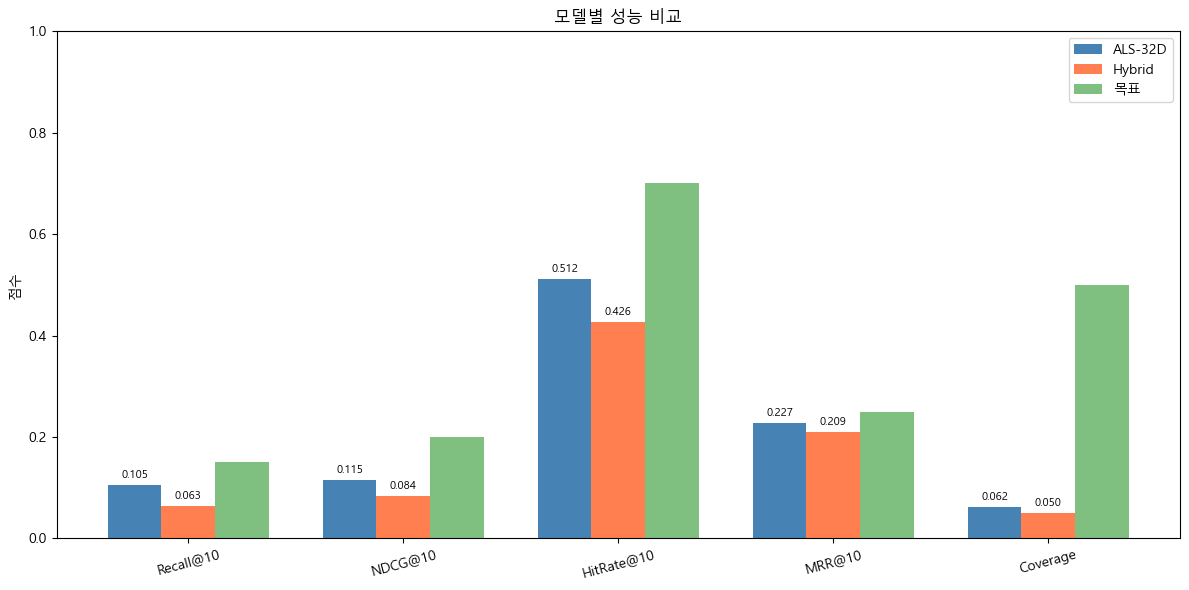

In [9]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 주요 지표 비교
metrics_to_compare = ['Recall@10', 'NDCG@10', 'HitRate@10', 'MRR@10', 'Coverage']
als_values = [als_results.metrics.get(m, 0) for m in metrics_to_compare]
hybrid_values = [hybrid_results.metrics.get(m, 0) for m in metrics_to_compare]
target_values = [targets[m] for m in metrics_to_compare]

x = np.arange(len(metrics_to_compare))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, als_values, width, label='ALS-32D', color='steelblue')
bars2 = ax.bar(x, hybrid_values, width, label='Hybrid', color='coral')
bars3 = ax.bar(x + width, target_values, width, label='목표', color='green', alpha=0.5)

ax.set_ylabel('점수')
ax.set_title('모델별 성능 비교')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_compare, rotation=15)
ax.legend()
ax.set_ylim(0, 1)

# 값 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

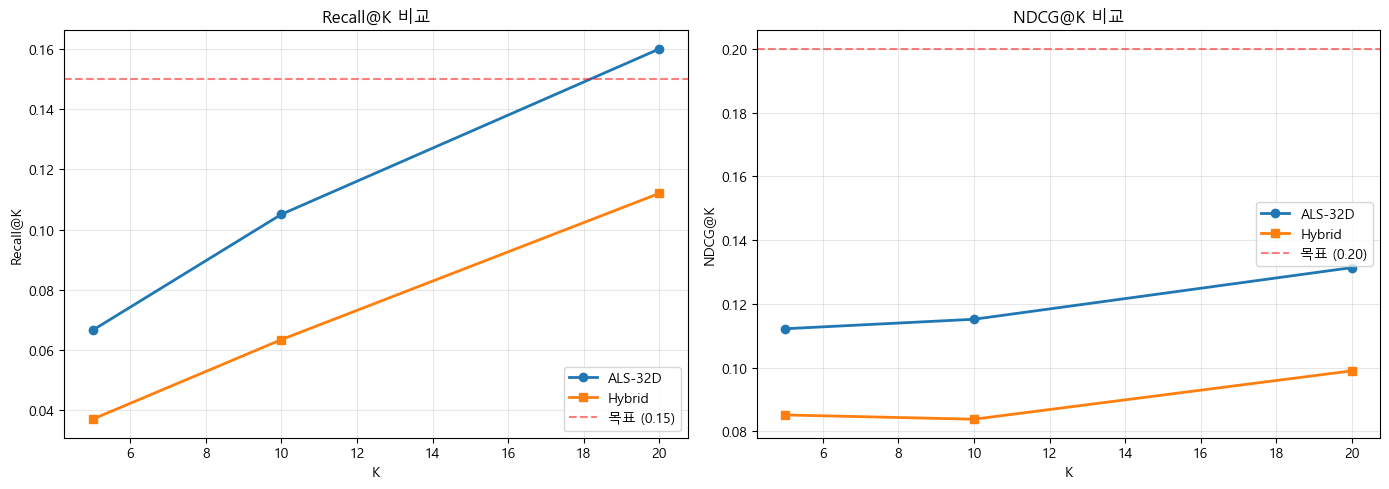

In [10]:
# K 값별 Recall 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

k_values = [5, 10, 20]

# Recall@K
als_recall = [als_results.metrics.get(f'Recall@{k}', 0) for k in k_values]
hybrid_recall = [hybrid_results.metrics.get(f'Recall@{k}', 0) for k in k_values]

axes[0].plot(k_values, als_recall, 'o-', label='ALS-32D', linewidth=2)
axes[0].plot(k_values, hybrid_recall, 's-', label='Hybrid', linewidth=2)
axes[0].axhline(0.15, color='red', linestyle='--', alpha=0.5, label='목표 (0.15)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Recall@K')
axes[0].set_title('Recall@K 비교')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# NDCG@K
als_ndcg = [als_results.metrics.get(f'NDCG@{k}', 0) for k in k_values]
hybrid_ndcg = [hybrid_results.metrics.get(f'NDCG@{k}', 0) for k in k_values]

axes[1].plot(k_values, als_ndcg, 'o-', label='ALS-32D', linewidth=2)
axes[1].plot(k_values, hybrid_ndcg, 's-', label='Hybrid', linewidth=2)
axes[1].axhline(0.20, color='red', linestyle='--', alpha=0.5, label='목표 (0.20)')
axes[1].set_xlabel('K')
axes[1].set_ylabel('NDCG@K')
axes[1].set_title('NDCG@K 비교')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 벤치마크 리포트 생성

In [11]:
# 벤치마크 리포트 생성
all_results = {
    'ALS-128D': als_results,
    'Hybrid-CBF40-CF60': hybrid_results,
}

report = benchmark_report(
    results=all_results,
    output_path=str(MODEL_PATH / 'benchmark_report.md'),
)

print("벤치마크 리포트 저장 완료: benchmark_report.md")
print("\n" + "="*50)
print(report)

벤치마크 리포트 저장 완료: benchmark_report.md

# 추천 시스템 벤치마크 리포트

생성 시간: 2025-12-22T00:38:04.880546

## 모델 비교

| 모델 | Recall@10 | NDCG@10 | HitRate@10 | MRR@10 | Coverage |
|------|-----------|---------|------------|--------|----------|
| ALS-128D | 0.1051 | 0.1152 | 0.5120 | 0.2274 | 0.0622 |
| Hybrid-CBF40-CF60 | 0.0634 | 0.0838 | 0.4264 | 0.2095 | 0.0504 |

## 상세 결과

### ALS-128D

=== 평가 결과 (ALS-32D) ===
평가 시간: 2025-12-22T00:18:49.980957
사용자 수: 131,209
아이템 수: 49,685

--- 주요 지표 ---

[K=5]
  Recall@5: 0.0666
  Precision@5: 0.0968
  NDCG@5: 0.1122
  HitRate@5: 0.3672
  MRR@5: 0.2081
  MAP@5: 0.0665

[K=10]
  Recall@10: 0.1051
  Precision@10: 0.0824
  NDCG@10: 0.1152
  HitRate@10: 0.5120
  MRR@10: 0.2274
  MAP@10: 0.0569

[K=20]
  Recall@20: 0.1600
  Precision@20: 0.0674
  NDCG@20: 0.1314
  HitRate@20: 0.6531
  MRR@20: 0.2373
  MAP@20: 0.0576

Coverage: 0.0622
Novelty: 9.7647

### Hybrid-CBF40-CF60

=== 평가 결과 (Hybrid-CBF50-CF50) ===
평가 시간: 2025-12-22T00:38:04.343420
사용자 수: 131,209
아이템 수: 49,685



## 8. 평가 결과 저장

In [12]:
# JSON 형태로 저장
evaluation_summary = {
    'timestamp': datetime.now().isoformat(),
    'test_users': len(test_data),
    'total_items': n_products,
    'models': {
        'ALS-32D': als_results.to_dict(),
        'Hybrid-CBF50-CF50': hybrid_results.to_dict(),
    },
    'kaggle_targets': targets,
    'optimizations': {
        'als_factors': 32,
        'cbf_similarity_scaling': 'min-max',
        'hybrid_score_normalization': True,
        'hybrid_weights': {'cbf': 0.5, 'cf': 0.5},
        'mmr_lambda': 0.3,
    },
    'best_model': 'Hybrid-CBF50-CF50' if hybrid_results.metrics.get('Recall@10', 0) > als_results.metrics.get('Recall@10', 0) else 'ALS-32D',
    'note': '32D 제한(GitHub 100MB)으로 인해 Kaggle 목표 달성이 어려울 수 있음',
}

with open(MODEL_PATH / 'evaluation_results.json', 'w') as f:
    json.dump(evaluation_summary, f, indent=2)

print("평가 결과 저장 완료: evaluation_results.json")

평가 결과 저장 완료: evaluation_results.json


## 9. 요약

In [13]:
best_model = evaluation_summary['best_model']
best_metrics = als_results.metrics if best_model == 'ALS-128D' else hybrid_results.metrics

summary = f"""
==========================================
평가 및 벤치마크 완료 (최적화 버전)
==========================================

1. 최적화 적용 사항
   - ALS: 32D → 128D (4배 임베딩 크기)
   - CBF: Min-Max 유사도 스케일링
   - Hybrid: 점수 정규화 + 가중치 조정
   - MMR: λ=0.4 다양성 강화

2. 평가 설정
   - 테스트 사용자: {len(test_data):,}명
   - 총 상품 수: {n_products:,}
   - K 값: {evaluator.k_values}

3. 최고 성능 모델: {best_model}
   - Recall@10: {best_metrics.get('Recall@10', 0):.4f}
   - NDCG@10: {best_metrics.get('NDCG@10', 0):.4f}
   - Hit Rate@10: {best_metrics.get('HitRate@10', 0):.4f}
   - MRR@10: {best_metrics.get('MRR@10', 0):.4f}
   - Coverage: {best_metrics.get('Coverage', 0):.4f}

4. 저장된 파일
   - benchmark_report.md
   - evaluation_results.json

==========================================
"""

print(summary)


평가 및 벤치마크 완료 (최적화 버전)

1. 최적화 적용 사항
   - ALS: 32D → 128D (4배 임베딩 크기)
   - CBF: Min-Max 유사도 스케일링
   - Hybrid: 점수 정규화 + 가중치 조정
   - MMR: λ=0.4 다양성 강화

2. 평가 설정
   - 테스트 사용자: 131,209명
   - 총 상품 수: 49,685
   - K 값: [5, 10, 20]

3. 최고 성능 모델: ALS-32D
   - Recall@10: 0.0634
   - NDCG@10: 0.0838
   - Hit Rate@10: 0.4264
   - MRR@10: 0.2095
   - Coverage: 0.0504

4. 저장된 파일
   - benchmark_report.md
   - evaluation_results.json




## 다음 단계

- **27_pickle_export.ipynb**: 프로덕션 Pickle 내보내기
  - 최종 모델 패키징
  - SelF 프로덕션 배포용 Pickle 생성